# 1. cleaning and pre-processing Engineering Faults csv

In [14]:


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [15]:
df = pd.read_csv("Engineering_Faults.csv")
df

,X_Minimum,X_Maximum,Y_Minimum,Y_Maximum,Pixels_Areas,X_Perimeter,Y_Perimeter,Sum_of_Luminosity,Minimum_of_Luminosity,Maximum_of_Luminosity,...,Orientation_Index,Luminosity_Index,SigmoidOfAreas,Pastry,Z_Scratch,K_Scatch,Stains,Dirtiness,Bumps,Other_Faults
0,42,50,270900,270944,267,17,44,24220,76,108,...,0.8182,-0.2913,0.5822,1,0,0,0,0,0,0
1,645,651,2538079,2538108,108,10,30,11397,84,123,...,0.7931,-0.1756,0.2984,1,0,0,0,0,0,0
2,829,835,1553913,1553931,71,8,19,7972,99,125,...,0.6667,-0.1228,0.2150,1,0,0,0,0,0,0
3,853,860,369370,369415,176,13,45,18996,99,126,...,0.8444,-0.1568,0.5212,1,0,0,0,0,0,0
4,1289,1306,498078,498335,2409,60,260,246930,37,126,...,0.9338,-0.1992,1.0000,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1936,249,277,325780,325796,273,54,22,35033,119,141,...,-0.4286,0.0026,0.7254,0,0,0,0,0,0,1
1937,144,175,340581,340598,287,44,24,34599,112,133,...,-0.4516,-0.0582,0.8173,0,0,0,0,0,0,1
1938,145,174,386779,386794,292,40,22,37572,120,140,...,-0.4828,0.0052,0.7079,0,0,0,0,0,0,1
1939,137,170,422497,422528,419,97,47,52715,117,140,...,-0.0606,-0.0171,0.9919,0,0,0,0,0,0,1


**checking the information of the dataset**

In [16]:
df.shape

(1941, 34)

In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1941 entries, 0 to 1940
Data columns (total 34 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   X_Minimum              1941 non-null   int64  
 1   X_Maximum              1941 non-null   int64  
 2   Y_Minimum              1941 non-null   int64  
 3   Y_Maximum              1941 non-null   int64  
 4   Pixels_Areas           1941 non-null   int64  
 5   X_Perimeter            1941 non-null   int64  
 6   Y_Perimeter            1941 non-null   int64  
 7   Sum_of_Luminosity      1941 non-null   int64  
 8   Minimum_of_Luminosity  1941 non-null   int64  
 9   Maximum_of_Luminosity  1941 non-null   int64  
 10  Length_of_Conveyer     1941 non-null   int64  
 11  TypeOfSteel_A300       1941 non-null   int64  
 12  TypeOfSteel_A400       1941 non-null   int64  
 13  Steel_Plate_Thickness  1941 non-null   int64  
 14  Edges_Index            1941 non-null   float64
 15  Empty_Index    

In [18]:
df.describe()

,X_Minimum,X_Maximum,Y_Minimum,Y_Maximum,Pixels_Areas,X_Perimeter,Y_Perimeter,Sum_of_Luminosity,Minimum_of_Luminosity,Maximum_of_Luminosity,...,Orientation_Index,Luminosity_Index,SigmoidOfAreas,Pastry,Z_Scratch,K_Scatch,Stains,Dirtiness,Bumps,Other_Faults
count,1941.000000,1941.000000,1.941000e+03,1.941000e+03,1941.000000,1941.000000,1941.000000,1.941000e+03,1941.000000,1941.000000,...,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000
mean,571.136012,617.964451,1.650685e+06,1.650739e+06,1893.878413,111.855229,82.965997,2.063121e+05,84.548686,130.193715,...,0.083288,-0.131305,0.585420,0.081401,0.097888,0.201443,0.037094,0.028336,0.207110,0.346728
std,520.690671,497.627410,1.774578e+06,1.774590e+06,5168.459560,301.209187,426.482879,5.122936e+05,32.134276,18.690992,...,0.500868,0.148767,0.339452,0.273521,0.297239,0.401181,0.189042,0.165973,0.405339,0.476051
min,0.000000,4.000000,6.712000e+03,6.724000e+03,2.000000,2.000000,1.000000,2.500000e+02,0.000000,37.000000,...,-0.991000,-0.998900,0.119000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,51.000000,192.000000,4.712530e+05,4.712810e+05,84.000000,15.000000,13.000000,9.522000e+03,63.000000,124.000000,...,-0.333300,-0.195000,0.248200,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,435.000000,467.000000,1.204128e+06,1.204136e+06,174.000000,26.000000,25.000000,1.920200e+04,90.000000,127.000000,...,0.095200,-0.133000,0.506300,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1053.000000,1072.000000,2.183073e+06,2.183084e+06,822.000000,84.000000,83.000000,8.301100e+04,106.000000,140.000000,...,0.511600,-0.066600,0.999800,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,1705.000000,1713.000000,1.298766e+07,1.298769e+07,152655.000000,10449.000000,18152.000000,1.159141e+07,203.000000,253.000000,...,0.991700,0.642100,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


**Checking for missing values**

In [19]:
df.isnull().any()

X_Minimum                False
X_Maximum                False
Y_Minimum                False
Y_Maximum                False
Pixels_Areas             False
X_Perimeter              False
Y_Perimeter              False
Sum_of_Luminosity        False
Minimum_of_Luminosity    False
Maximum_of_Luminosity    False
Length_of_Conveyer       False
TypeOfSteel_A300         False
TypeOfSteel_A400         False
Steel_Plate_Thickness    False
Edges_Index              False
Empty_Index              False
Square_Index             False
Outside_X_Index          False
Edges_X_Index            False
Edges_Y_Index            False
Outside_Global_Index     False
LogOfAreas               False
Log_X_Index              False
Log_Y_Index              False
Orientation_Index        False
Luminosity_Index         False
SigmoidOfAreas           False
Pastry                   False
Z_Scratch                False
K_Scatch                 False
Stains                   False
Dirtiness                False
Bumps   

**Checking for duplicates**

In [20]:
df.duplicated().any()

np.False_

In [21]:
df.columns

Index(['X_Minimum', 'X_Maximum', 'Y_Minimum', 'Y_Maximum', 'Pixels_Areas',
       'X_Perimeter', 'Y_Perimeter', 'Sum_of_Luminosity',
       'Minimum_of_Luminosity', 'Maximum_of_Luminosity', 'Length_of_Conveyer',
       'TypeOfSteel_A300', 'TypeOfSteel_A400', 'Steel_Plate_Thickness',
       'Edges_Index', 'Empty_Index', 'Square_Index', 'Outside_X_Index',
       'Edges_X_Index', 'Edges_Y_Index', 'Outside_Global_Index', 'LogOfAreas',
       'Log_X_Index', 'Log_Y_Index', 'Orientation_Index', 'Luminosity_Index',
       'SigmoidOfAreas', 'Pastry', 'Z_Scratch', 'K_Scatch', 'Stains',
       'Dirtiness', 'Bumps', 'Other_Faults'],
      dtype='str')

--checking for number of unique values

In [22]:
df.nunique()

X_Minimum                 962
X_Maximum                 994
Y_Minimum                1939
Y_Maximum                1940
Pixels_Areas              920
X_Perimeter               399
Y_Perimeter               317
Sum_of_Luminosity        1909
Minimum_of_Luminosity     161
Maximum_of_Luminosity     100
Length_of_Conveyer         84
TypeOfSteel_A300            2
TypeOfSteel_A400            2
Steel_Plate_Thickness      24
Edges_Index              1387
Empty_Index              1338
Square_Index              770
Outside_X_Index           454
Edges_X_Index             818
Edges_Y_Index             648
Outside_Global_Index        3
LogOfAreas                914
Log_X_Index               183
Log_Y_Index               217
Orientation_Index         918
Luminosity_Index         1522
SigmoidOfAreas            388
Pastry                      2
Z_Scratch                   2
K_Scatch                    2
Stains                      2
Dirtiness                   2
Bumps                       2
Other_Faul

**dropping columns with minimum number of unique values**

In [23]:
df_drop = df.drop(columns =["TypeOfSteel_A300",
        "TypeOfSteel_A400",
        "Outside_Global_Index",
        "Pastry",
        "Z_Scratch",
        "K_Scatch",
        "Stains",
        "Dirtiness",
        "Bumps",
        "Other_Faults"])

df_drop

,X_Minimum,X_Maximum,Y_Minimum,Y_Maximum,Pixels_Areas,X_Perimeter,Y_Perimeter,Sum_of_Luminosity,Minimum_of_Luminosity,Maximum_of_Luminosity,...,Square_Index,Outside_X_Index,Edges_X_Index,Edges_Y_Index,LogOfAreas,Log_X_Index,Log_Y_Index,Orientation_Index,Luminosity_Index,SigmoidOfAreas
0,42,50,270900,270944,267,17,44,24220,76,108,...,0.1818,0.0047,0.4706,1.0000,2.4265,0.9031,1.6435,0.8182,-0.2913,0.5822
1,645,651,2538079,2538108,108,10,30,11397,84,123,...,0.2069,0.0036,0.6000,0.9667,2.0334,0.7782,1.4624,0.7931,-0.1756,0.2984
2,829,835,1553913,1553931,71,8,19,7972,99,125,...,0.3333,0.0037,0.7500,0.9474,1.8513,0.7782,1.2553,0.6667,-0.1228,0.2150
3,853,860,369370,369415,176,13,45,18996,99,126,...,0.1556,0.0052,0.5385,1.0000,2.2455,0.8451,1.6532,0.8444,-0.1568,0.5212
4,1289,1306,498078,498335,2409,60,260,246930,37,126,...,0.0662,0.0126,0.2833,0.9885,3.3818,1.2305,2.4099,0.9338,-0.1992,1.0000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1936,249,277,325780,325796,273,54,22,35033,119,141,...,0.5714,0.0206,0.5185,0.7273,2.4362,1.4472,1.2041,-0.4286,0.0026,0.7254
1937,144,175,340581,340598,287,44,24,34599,112,133,...,0.5484,0.0228,0.7046,0.7083,2.4579,1.4914,1.2305,-0.4516,-0.0582,0.8173
1938,145,174,386779,386794,292,40,22,37572,120,140,...,0.5172,0.0213,0.7250,0.6818,2.4654,1.4624,1.1761,-0.4828,0.0052,0.7079
1939,137,170,422497,422528,419,97,47,52715,117,140,...,0.9394,0.0243,0.3402,0.6596,2.6222,1.5185,1.4914,-0.0606,-0.0171,0.9919


**Checking for outliers**
- column = Sum_of_Luminosity

In [24]:
df["Sum_of_Luminosity"]

0        24220
1        11397
2         7972
3        18996
4       246930
         ...  
1936     35033
1937     34599
1938     37572
1939     52715
1940     11682
Name: Sum_of_Luminosity, Length: 1941, dtype: int64

In [25]:
Q1 = df["Sum_of_Luminosity"].quantile(0.25)
Q3 = df["Sum_of_Luminosity"].quantile(0.75)

IQR = Q3 - Q1 
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df["Sum_of_Luminosity"] < lower) | (df["Sum_of_Luminosity"] > upper)] 

outliers

,X_Minimum,X_Maximum,Y_Minimum,Y_Maximum,Pixels_Areas,X_Perimeter,Y_Perimeter,Sum_of_Luminosity,Minimum_of_Luminosity,Maximum_of_Luminosity,...,Orientation_Index,Luminosity_Index,SigmoidOfAreas,Pastry,Z_Scratch,K_Scatch,Stains,Dirtiness,Bumps,Other_Faults
4,1289,1306,498078,498335,2409,60,260,246930,37,126,...,0.9338,-0.1992,1.0,1,0,0,0,0,0,0
6,413,446,138468,138883,9052,230,432,1481991,23,199,...,0.9205,0.2791,1.0,1,0,0,0,0,0,0
16,156,192,713788,714056,5044,167,282,570911,11,143,...,0.8657,-0.1157,1.0,1,0,0,0,0,0,0
28,1281,1302,4332564,4332815,3214,92,253,368381,33,140,...,0.9163,-0.1045,1.0,1,0,0,0,0,0,0
78,124,140,2377039,2377320,2643,165,285,300024,64,140,...,0.9431,-0.1132,1.0,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1709,113,153,310621,310797,2281,365,268,287273,113,143,...,0.7727,-0.0161,1.0,0,0,0,0,0,0,1
1748,325,361,58567,58747,2059,134,200,374117,169,199,...,0.8000,0.4195,1.0,0,0,0,0,0,0,1
1749,605,736,2066548,2066684,1981,219,206,230693,104,127,...,0.0368,-0.0902,1.0,0,0,0,0,0,0,1
1793,779,803,1689276,1689652,4758,307,377,517021,42,143,...,0.9362,-0.1511,1.0,0,0,0,0,0,0,1


**Using Min-Max Scaling method to scale through columns that has ambigous numbers**

In [27]:
from sklearn.preprocessing import MinMaxScaler

ModuleNotFoundError: No module named 'sklearn'

In [ ]:
scaler = MinMaxScaler()
df[["X_Minimum",
    "X_Maximum", 
    "Y_Minimum",
    "Y_Maximum",
    "Pixels_Areas",
    "X_Perimeter",
    "Y_Perimeter",
    "Sum_of_Luminosity",
    "Minimum_of_Luminosity",
    "Maximum_of_Luminosity",
    ]] = scaler.fit_transform(df[["X_Minimum",
    "X_Maximum", 
    "Y_Minimum",
    "Y_Maximum",
    "Pixels_Areas",
    "X_Perimeter",
    "Y_Perimeter",
    "Sum_of_Luminosity",
    "Minimum_of_Luminosity",
    "Maximum_of_Luminosity",
    ]])

In [ ]:
df

,X_Minimum,X_Maximum,Y_Minimum,Y_Maximum,Pixels_Areas,X_Perimeter,Y_Perimeter,Sum_of_Luminosity,Minimum_of_Luminosity,Maximum_of_Luminosity,...,Orientation_Index,Luminosity_Index,SigmoidOfAreas,Pastry,Z_Scratch,K_Scatch,Stains,Dirtiness,Bumps,Other_Faults
0,0.024633,0.026916,0.020352,0.020354,0.001736,0.001436,0.002369,0.002068,0.374384,0.328704,...,0.8182,-0.2913,0.5822,1,0,0,0,0,0,0
1,0.378299,0.378584,0.195006,0.195007,0.000694,0.000766,0.001598,0.000962,0.413793,0.398148,...,0.7931,-0.1756,0.2984,1,0,0,0,0,0,0
2,0.486217,0.486249,0.119190,0.119190,0.000452,0.000574,0.000992,0.000666,0.487685,0.407407,...,0.6667,-0.1228,0.2150,1,0,0,0,0,0,0
3,0.500293,0.500878,0.027938,0.027940,0.001140,0.001053,0.002424,0.001617,0.487685,0.412037,...,0.8444,-0.1568,0.5212,1,0,0,0,0,0,0
4,0.756012,0.761849,0.037853,0.037872,0.015768,0.005552,0.014269,0.021282,0.182266,0.412037,...,0.9338,-0.1992,1.0000,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1936,0.146041,0.159743,0.024580,0.024580,0.001775,0.004978,0.001157,0.003001,0.586207,0.481481,...,-0.4286,0.0026,0.7254,0,0,0,0,0,0,1
1937,0.084457,0.100059,0.025720,0.025720,0.001867,0.004020,0.001267,0.002963,0.551724,0.444444,...,-0.4516,-0.0582,0.8173,0,0,0,0,0,0,1
1938,0.085044,0.099473,0.029279,0.029279,0.001900,0.003637,0.001157,0.003220,0.591133,0.476852,...,-0.4828,0.0052,0.7079,0,0,0,0,0,0,1
1939,0.080352,0.097133,0.032030,0.032032,0.002732,0.009094,0.002534,0.004526,0.576355,0.476852,...,-0.0606,-0.0171,0.9919,0,0,0,0,0,0,1


# Visualizing the appropriate insights from the dataset
- where The last seven columns are one hot encoded classes, i.e. if the plate fault is classified as "Stains" there will be a 1 in that column and 0's in the other columns.
- the last seven columns represents the fualt type in the steel plates dataset

In [28]:
fault_type = df.iloc[:,-7:]
fault_type

,Pastry,Z_Scratch,K_Scatch,Stains,Dirtiness,Bumps,Other_Faults
0,1,0,0,0,0,0,0
1,1,0,0,0,0,0,0
2,1,0,0,0,0,0,0
3,1,0,0,0,0,0,0
4,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...
1936,0,0,0,0,0,0,1
1937,0,0,0,0,0,0,1
1938,0,0,0,0,0,0,1
1939,0,0,0,0,0,0,1


In [29]:
steel_faults = list(fault_type.columns)
steel_faults

['Pastry',
 'Z_Scratch',
 'K_Scatch',
 'Stains',
 'Dirtiness',
 'Bumps',
 'Other_Faults']

In [30]:
sl_faults = np.array(steel_faults)
sl_faults

array(['Pastry', 'Z_Scratch', 'K_Scatch', 'Stains', 'Dirtiness', 'Bumps',
       'Other_Faults'], dtype='<U12')

In [31]:
fault_value = fault_type[["Pastry",
            "Z_Scratch", 
            "K_Scatch",
            "Stains", 
            "Dirtiness",
            "Bumps", 
            "Other_Faults"]].sum()
fault_value

Pastry          158
Z_Scratch       190
K_Scatch        391
Stains           72
Dirtiness        55
Bumps           402
Other_Faults    673
dtype: int64

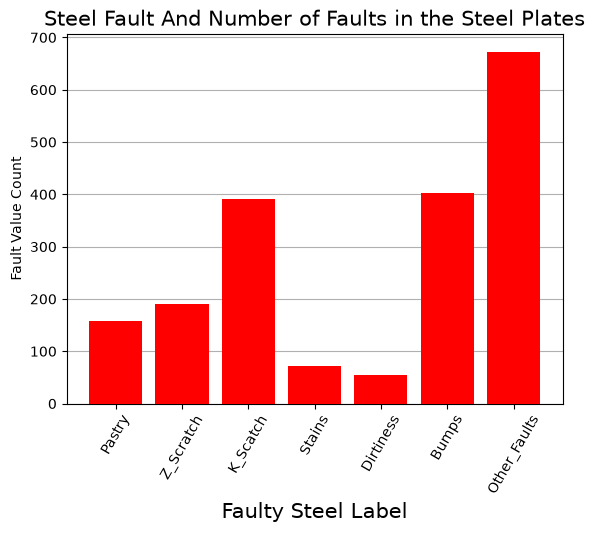

In [34]:
plt.bar(sl_faults, fault_value, color="r", zorder=3)
plt.tight_layout
plt.xlabel("Faulty Steel Label", fontsize= 15)
plt.xticks(rotation= 60)
plt.ylabel("Fault Value Count", fontsize= 10)
plt.title("Steel Fault And Number of Faults in the Steel Plates", 
         fontsize= 15)
plt.grid(True, axis="y", zorder=0)
plt.savefig('eda_defect_distribution.png', dpi=150)
plt.show()